# 📈 Stock Trend Prediction — Transformer + GNN

**Architecture:** Temporal Transformer × Graph Neural Network with two heads:
- 🟢 **GNN** → Models inter-stock dependencies (sector contagion, supply chains)
- 🔴 **Classification Head** → Trend Direction (UP / DOWN / NEUTRAL)
- 🔵 **Regression Head** → Next-day Closing Price

```
Input [B, N, T, F]
   │
TemporalTransformer  ← shared weights per stock, 4× Encoder layers
   │  Positional Encoding + Global Avg Pool
   ↓
Node Embeddings [B, N, D]
   │
GCNLayer × 2  ← A = correlation-based adjacency (N×N)
   │  H' = σ(A_norm · H · W)   inter-stock message passing
   ↓
Enriched Node Embeddings + Residual
   │
Dual Heads (per stock)
   ├── Classification → UP / NEUTRAL / DOWN
   └── Regression    → next-day close price
```

**Stocks:** 28 Indian Banking & NBFC stocks (NSE)  
**Features:** OHLCV + RSI, MACD, Returns, Volatility (F=12), SEQ_LEN=20


## 📦 Section 1 — Install & Import Dependencies

In [1]:
import importlib, subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['yfinance', 'scikit-learn']:
    if importlib.util.find_spec(pkg.split('[')[0].replace('-','_')) is None:
        install(pkg)
        print(f'Installed {pkg}')


Installed scikit-learn


In [2]:
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import yfinance as yf

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')


Device : cuda
PyTorch: 2.11.0+cu128


---
## 🏗️ Section 2 — Data Loading (Yahoo Finance → OHLCV)

Downloads real OHLCV data for **28 Indian Banking & NBFC stocks** via `yfinance`
and engineers 12 technical features per stock.


In [3]:
TICKER_MAP = {
    'HDFCBANK'   : 'HDFCBANK.NS',   'IDFCFIRST'  : 'IDFCFIRSTB.NS',
    'ICICI'      : 'ICICIBANK.NS',  'KOTAK'       : 'KOTAKBANK.NS',
    'AXIS'       : 'AXISBANK.NS',   'SBI'         : 'SBIN.NS',
    'INDUSIND'   : 'INDUSINDBK.NS', 'UNION BANK'  : 'UNIONBANK.NS',
    'FEDERAL'    : 'FEDERALBNK.NS', 'BOB'         : 'BANKBARODA.NS',
    'PNB'        : 'PNB.NS',        'BANDHAN'     : 'BANDHANBNK.NS',
    'CANARA'     : 'CANBK.NS',      'INDIAN'      : 'INDIANB.NS',
    'UCO'        : 'UCOBANK.NS',    'BOI'         : 'BANKINDIA.NS',
    'SOUTH'      : 'SOUTHBANK.NS',  'CBOI'        : 'CENTRALBK.NS',
    'KARUR'      : 'KARURVYSYA.NS', 'YES'         : 'YESBANK.NS',
    'EQUITAS'    : 'EQUITASBNK.NS', 'UJJIVANS'    : 'UJJIVANSFB.NS',
    'BAJFINA'    : 'BAJFINANCE.NS', 'BAJFINS'     : 'BAJAJFINSV.NS',
    'MUTHOOTFIN' : 'MUTHOOTFIN.NS', 'MANAPPURAM'  : 'MANAPPURAM.NS',
    'IIFL'       : 'IIFL.NS',       'J&K'         : 'J&KBANK.NS',
}
STOCKS = list(TICKER_MAP.keys())

FEATURE_COLS = ['open', 'high', 'low', 'close', 'volume',
                'ret_1D', 'ret_3D', 'ret_7D', 'rsi', 'macd',
                'volatility_7D', 'volume_change']
SEQ_LEN     = 20

TRAIN_RATIO = 0.75
VAL_RATIO   = 0.10


In [4]:
def yf_to_price_df(ticker_map, start='2021-01-01', end=None):
    """Download OHLCV from Yahoo Finance → long-format DataFrame."""
    tickers = list(ticker_map.values())
    reverse = {v: k for k, v in ticker_map.items()}
    raw = yf.download(tickers, start=start, end=end,
                      auto_adjust=True, progress=False)
    records = []
    for ticker in tickers:
        stock_id = reverse[ticker]
        try:
            df_t = raw.xs(ticker, axis=1, level=1).copy()
        except KeyError:
            print(f'  ⚠️  {ticker} not found — skipping')
            continue
        df_t = df_t.rename(columns=str.lower)
        df_t.index.name = 'date'
        df_t = df_t.reset_index()
        df_t['date']     = pd.to_datetime(df_t['date']).dt.tz_localize(None)
        df_t['stock_id'] = stock_id
        df_t = df_t[['date', 'stock_id', 'open', 'high', 'low', 'close', 'volume']]
        df_t = df_t.dropna(subset=['close'])
        records.append(df_t)
    price_df = pd.concat(records, ignore_index=True)
    return price_df.sort_values(['stock_id', 'date']).reset_index(drop=True)


def compute_technical_features(price_df):
    """Add RSI, MACD, return & volatility features."""
    dfs = []
    for stock_id, grp in price_df.groupby('stock_id'):
        grp = grp.sort_values('date').copy()
        c, v = grp['close'], grp['volume']
        grp['ret_1D']        = c.pct_change(1)
        grp['ret_3D']        = c.pct_change(3)
        grp['ret_7D']        = c.pct_change(7)
        grp['volatility_7D'] = c.pct_change().rolling(7).std()
        grp['volume_change'] = v.pct_change(1)
        delta = c.diff()
        gain  = delta.clip(lower=0).rolling(14).mean()
        loss  = (-delta.clip(upper=0)).rolling(14).mean()
        grp['rsi']  = 100 - (100 / (1 + gain / (loss + 1e-9)))
        ema12 = c.ewm(span=12, adjust=False).mean()
        ema26 = c.ewm(span=26, adjust=False).mean()
        grp['macd'] = ema12 - ema26
        dfs.append(grp)
    return pd.concat(dfs).reset_index(drop=True)


In [5]:
print('Downloading real OHLCV data from Yahoo Finance...')
price_df  = yf_to_price_df(TICKER_MAP, start='2018-01-01')
full_data = compute_technical_features(price_df)
full_data = full_data.dropna().reset_index(drop=True)

# Keep only stocks with complete data
available_stocks = [s for s in STOCKS if s in full_data['stock_id'].unique()]
full_data  = full_data[full_data['stock_id'].isin(available_stocks)]
N_STOCKS   = len(available_stocks)

print(f'price_data shape : {price_df.shape}')
print(f'full_data shape  : {full_data.shape}')
print(f'Stocks loaded    : {N_STOCKS} — {available_stocks}')
print(f'Date range       : {full_data.date.min().date()} → {full_data.date.max().date()}')
full_data.head(3)


price_data shape : (55748, 7)
full_data shape  : (55355, 14)
Stocks loaded    : 28 — ['HDFCBANK', 'IDFCFIRST', 'ICICI', 'KOTAK', 'AXIS', 'SBI', 'INDUSIND', 'UNION BANK', 'FEDERAL', 'BOB', 'PNB', 'BANDHAN', 'CANARA', 'INDIAN', 'UCO', 'BOI', 'SOUTH', 'CBOI', 'KARUR', 'YES', 'EQUITAS', 'UJJIVANS', 'BAJFINA', 'BAJFINS', 'MUTHOOTFIN', 'MANAPPURAM', 'IIFL', 'J&K']
Date range       : 2018-01-19 → 2026-03-27


Price,date,stock_id,open,high,low,close,volume,ret_1D,ret_3D,ret_7D,volatility_7D,volume_change,rsi,macd
0,2018-01-19,AXIS,581.745589,590.796487,578.065531,587.066711,3897048.0,0.009320,0.048029,0.048774,0.015759,-0.588354,70.850820,3.768409
1,2018-01-22,AXIS,592.735988,618.396833,580.005032,608.251831,21790443.0,0.036086,0.045027,0.094497,0.017668,4.591525,84.862619,6.646343
2,2018-01-23,AXIS,613.075740,624.215289,608.152424,616.755737,14286343.0,0.013981,0.060363,0.117096,0.015425,-0.344376,86.261330,9.503768


---
## 🔍 Section 3 — Exploratory Data Analysis


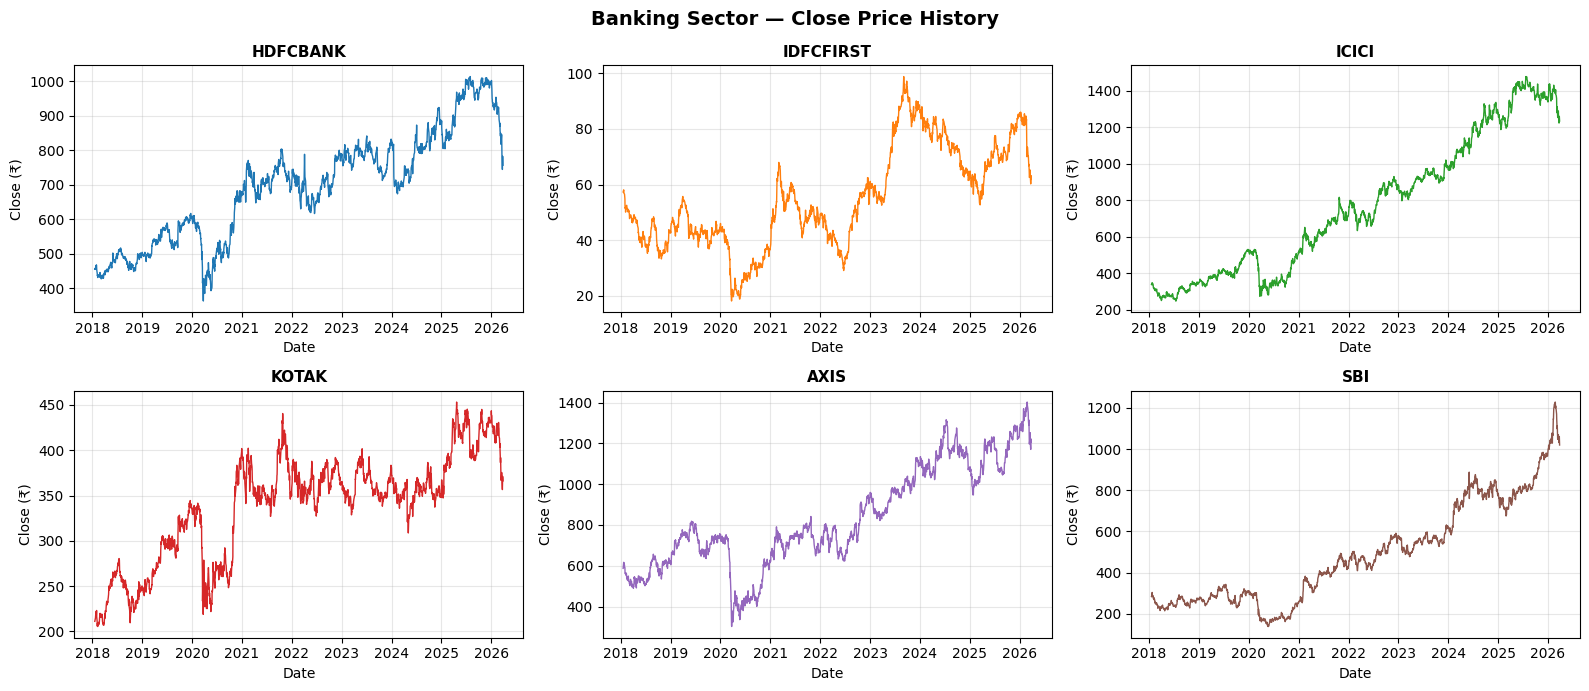

In [6]:
# ── Price history for first 6 stocks ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
fig.suptitle('Banking Sector — Close Price History', fontsize=14, fontweight='bold')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for ax, stock, color in zip(axes.flat, available_stocks[:6], colors):
    grp = full_data[full_data['stock_id'] == stock].sort_values('date')
    ax.plot(grp['date'], grp['close'], color=color, linewidth=1)
    ax.set_title(stock, fontsize=11, fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('Close (₹)')
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


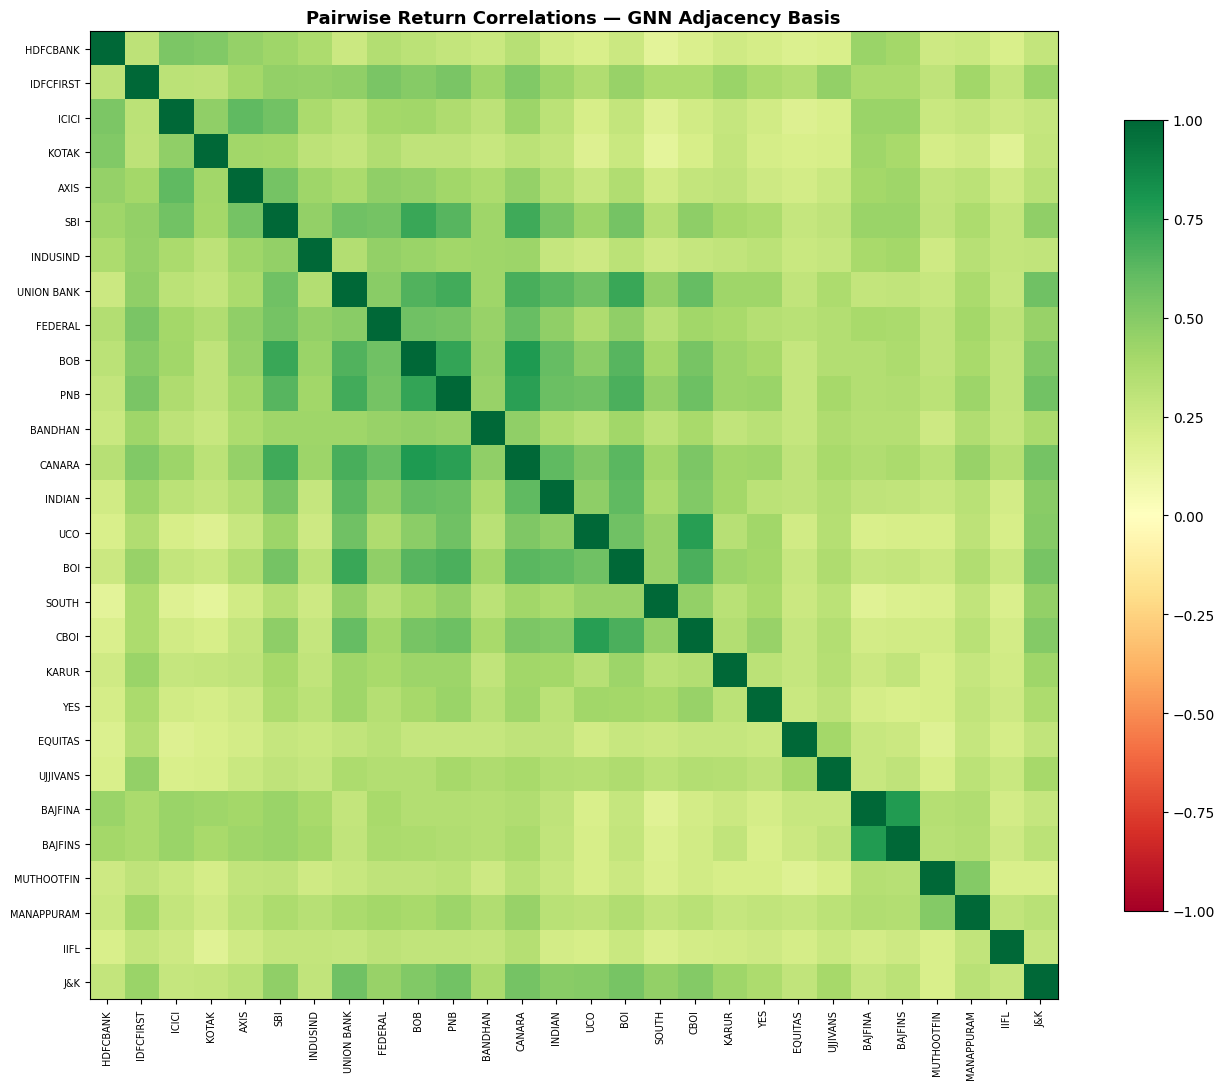

Mean cross-stock correlation: 0.366


In [7]:
# ── Correlation heatmap ────────────────────────────────────────────────────────
pivot_ret = full_data.pivot(index='date', columns='stock_id', values='ret_1D')
pivot_ret = pivot_ret[available_stocks].dropna()
corr = pivot_ret.corr()

fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(N_STOCKS)); ax.set_yticks(range(N_STOCKS))
ax.set_xticklabels(available_stocks, rotation=90, fontsize=7)
ax.set_yticklabels(available_stocks, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title('Pairwise Return Correlations — GNN Adjacency Basis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Mean cross-stock correlation: {corr.values[corr.values < 1].mean():.3f}')


---
## 🧩 Section 4 — Label Engineering

**Regression target:** `next_close` — next trading day's closing price  
**Classification target:** `trend` — 3-class label  
- `2` → UP   (return > +0.5%)  
- `1` → NEUTRAL  
- `0` → DOWN (return < −0.5%)


In [8]:
THRESHOLD   = 0.007   # 0.5 % band for UP / DOWN / NEUTRAL

dfs = []
for sid, grp in full_data.groupby('stock_id'):
    grp = grp.sort_values('date').copy()
    grp['next_close'] = grp['close'].shift(-1)
    ret = (grp['next_close'] - grp['close']) / (grp['close'] + 1e-9)
    grp['trend'] = np.where(ret > THRESHOLD, 2,
                   np.where(ret < -THRESHOLD, 0, 1))
    dfs.append(grp)

labeled = pd.concat(dfs).dropna().reset_index(drop=True)

# Class distribution
from collections import Counter
counts = Counter(labeled['trend'].values)
labels_map = {0: 'DOWN', 1: 'NEUTRAL', 2: 'UP'}
print('Trend class distribution (all stocks combined):')
total = sum(counts.values())
for k in [0, 1, 2]:
    print(f'  {labels_map[k]:>8}: {counts[k]:6,}  ({counts[k]/total:.1%})')


Trend class distribution (all stocks combined):
      DOWN: 18,802  (34.0%)
   NEUTRAL: 18,287  (33.1%)
        UP: 18,238  (33.0%)


---
## 🕸️ Section 5 — Graph Dataset

Each training sample is a **graph snapshot**: all N stocks at one time step.

```
Sample shape: (N, T, F)
  N = number of stocks
  T = SEQ_LEN = 20
  F = 12 features
```

The `GraphStockDataset` slides a window of 20 days across all dates simultaneously,
so all stocks share the same temporal context at each step.


In [9]:
class GraphStockDataset(Dataset):
    """
    Returns one graph snapshot per sample:
        X  : (N, T, F)  — all N stocks, SEQ_LEN time steps, F features
        yc : (N,)       — classification label per stock
        yr : (N,)       — regression label per stock
    """
    def __init__(self, pivot_X, pivot_yc, pivot_yr):
        T_total = pivot_X.shape[0]
        samples_X, samples_yc, samples_yr = [], [], []
        for i in range(SEQ_LEN, T_total):
            samples_X.append(pivot_X[i - SEQ_LEN : i])
            samples_yc.append(pivot_yc[i])
            samples_yr.append(pivot_yr[i])

        # (S, T, N, F) → permute → (S, N, T, F)
        self.X  = torch.tensor(np.stack(samples_X),
                               dtype=torch.float32).permute(0, 2, 1, 3)
        self.yc = torch.tensor(np.stack(samples_yc), dtype=torch.long)
        self.yr = torch.tensor(np.stack(samples_yr), dtype=torch.float32)

    def __len__(self):  return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.yc[idx], self.yr[idx]


def build_graph_dataset(df, stocks, scaler=None, fit_scaler=False):
    """Pivot features into (T, N, F) aligned on common trading dates."""
    pivot_close  = df.pivot(index='date', columns='stock_id', values='close')
    common_dates = pivot_close.dropna().index
    df_aligned   = df[df['date'].isin(common_dates)]

    feat_list, yc_list, yr_list = [], [], []
    for date in sorted(common_dates):
        day = df_aligned[df_aligned['date'] == date].set_index('stock_id')
        if not all(s in day.index for s in stocks):
            continue
        feat_list.append(day.loc[stocks, FEATURE_COLS].values)
        yc_list.append(day.loc[stocks, 'trend'].values)
        yr_list.append(day.loc[stocks, 'next_close'].values)

    X  = np.nan_to_num(np.stack(feat_list), nan=0.0, posinf=0.0, neginf=0.0)
    yc = np.stack(yc_list)
    yr = np.stack(yr_list)

    T, N, F = X.shape
    X_flat = X.reshape(-1, F)
    if fit_scaler and scaler is not None: scaler.fit(X_flat)
    if scaler is not None:                X_flat = scaler.transform(X_flat)
    return X_flat.reshape(T, N, F), yc, yr


def build_correlation_adjacency(df, stocks, threshold=0.3):
    """
    Build row-normalised adjacency matrix from pairwise return correlations.
    Edge exists where |corr| >= threshold. Self-loops always present.
    Returns A: (N, N) numpy float32.
    """
    pivot = df.pivot(index='date', columns='stock_id', values='ret_1D')
    pivot = pivot[stocks].dropna()
    corr  = pivot.corr().values
    A = (np.abs(corr) >= threshold).astype(np.float32)
    np.fill_diagonal(A, 1.0)
    A_norm = A / (A.sum(axis=1, keepdims=True) + 1e-9)
    return A_norm


In [10]:
# ── Chronological split on dates (not per-stock) ──────────────────────────────
all_dates = sorted(labeled['date'].unique())
T_total   = len(all_dates)
t1 = int(T_total * TRAIN_RATIO)
t2 = int(T_total * (TRAIN_RATIO + VAL_RATIO))

df_train = labeled[labeled['date'].isin(all_dates[:t1])]
df_val   = labeled[labeled['date'].isin(all_dates[t1:t2])]
df_test  = labeled[labeled['date'].isin(all_dates[t2:])]

# Build graph arrays
scaler = StandardScaler()
X_tr,  yc_tr,  yr_tr  = build_graph_dataset(df_train, available_stocks, scaler, fit_scaler=True)
X_val, yc_val, yr_val = build_graph_dataset(df_val,   available_stocks, scaler)
X_te,  yc_te,  yr_te  = build_graph_dataset(df_test,  available_stocks, scaler)

# Normalise regression targets
yr_mean, yr_std = yr_tr.mean(), yr_tr.std()
yr_tr_n  = (yr_tr  - yr_mean) / yr_std
yr_val_n = (yr_val - yr_mean) / yr_std
yr_te_n  = (yr_te  - yr_mean) / yr_std

BATCH = 32
train_loader = DataLoader(GraphStockDataset(X_tr,  yc_tr,  yr_tr_n),
                          batch_size=BATCH, shuffle=True,  drop_last=True)
val_loader   = DataLoader(GraphStockDataset(X_val, yc_val, yr_val_n),
                          batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(GraphStockDataset(X_te,  yc_te,  yr_te_n),
                          batch_size=BATCH, shuffle=False)

print(f'Train samples : {len(train_loader.dataset):,}')
print(f'Val   samples : {len(val_loader.dataset):,}')
print(f'Test  samples : {len(test_loader.dataset):,}')
print(f'Feature dim   : {X_tr.shape[2]}   N stocks: {X_tr.shape[1]}')


Train samples : 797
Val   samples : 182
Test  samples : 282
Feature dim   : 12   N stocks: 28


Adjacency matrix shape : (28, 28)
Avg node degree        : 17.9
Edge density           : 63.78%


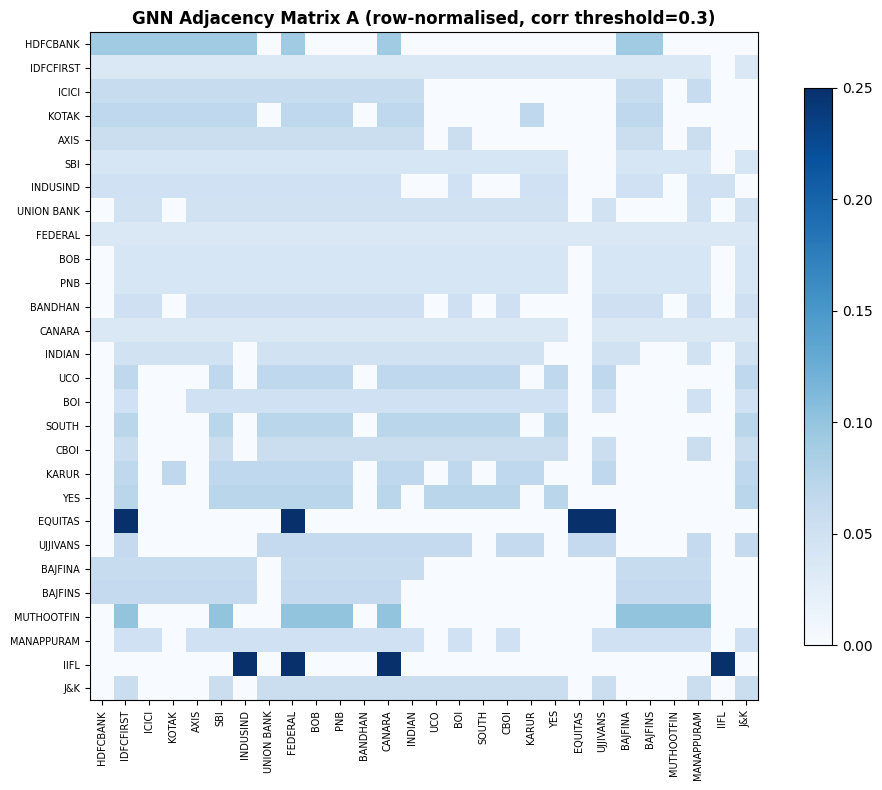

In [11]:
# ── Build adjacency matrix & visualise ────────────────────────────────────────
A_np     = build_correlation_adjacency(df_train, available_stocks, threshold=0.3)
A_tensor = torch.tensor(A_np, dtype=torch.float32).to(DEVICE)

print(f'Adjacency matrix shape : {A_np.shape}')
print(f'Avg node degree        : {(A_np > 0).sum(1).mean():.1f}')
print(f'Edge density           : {(A_np > 0).mean():.2%}')

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(A_np, cmap='Blues')
ax.set_xticks(range(N_STOCKS)); ax.set_yticks(range(N_STOCKS))
ax.set_xticklabels(available_stocks, rotation=90, fontsize=7)
ax.set_yticklabels(available_stocks, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title('GNN Adjacency Matrix A (row-normalised, corr threshold=0.3)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 🤖 Section 6 — Transformer + GNN Model Architecture

```
Input (B, N, T, F)
    │
    ├─[reshape]─► (B×N, T, F)
    │
TemporalTransformer  [shared weights across all N stocks]
    │  Linear Projection → Positional Encoding
    │  4× TransformerEncoderLayer (pre-norm, nhead=4, ff=512)
    │  Global Average Pool
    │
    └─[reshape]─► Node Embeddings (B, N, 128)
                        │
                  GCNLayer × 2   H' = σ(A_norm · H · W)
                        │
                  Residual Add (B, N, 128)
                        │
                  Shared MLP  →  64-dim
                        │
            ┌───────────┴───────────┐
     Classification Head      Regression Head
       Linear(64→32→3)          Linear(64→32→1)
       (B, N, 3)                  (B, N)
```


In [12]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


In [13]:
class TemporalTransformer(nn.Module):
    """
    Encodes a single stock's time-series window (T, F) → embedding (d_model,).
    Shared weights — applied to every stock in the batch simultaneously.
    """
    def __init__(self, input_dim, d_model=128, nhead=4,
                 num_layers=4, dropout=0.1):
        super().__init__()
        self.input_proj  = nn.Linear(input_dim, d_model)
        self.pos_enc     = PositionalEncoding(d_model, dropout=dropout)
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm        = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (B*N, T, F)
        x = self.input_proj(x)   # (B*N, T, d_model)
        x = self.pos_enc(x)
        x = self.transformer(x)  # (B*N, T, d_model)
        return self.norm(x).mean(dim=1)   # global avg pool → (B*N, d_model)


In [14]:
class GCNLayer(nn.Module):
    """
    Graph Convolution: H' = σ( A_norm · H · W )
    A_norm is the pre-computed row-normalised adjacency (D^{-1} A).
    """
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.W    = nn.Linear(in_dim, out_dim, bias=False)
        self.norm = nn.LayerNorm(out_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, H, A):
        # H: (B, N, in_dim)   A: (N, N)
        AH  = torch.bmm(A.unsqueeze(0).expand(H.size(0), -1, -1), H)
        out = self.W(AH)
        return self.drop(F.gelu(self.norm(out)))


In [15]:
class TransformerGNNDualHead(nn.Module):
    """
    Full model: TemporalTransformer + GCN layers + dual prediction heads.

    Args
    ----
    input_dim       : number of input features F (12)
    num_stocks      : N
    d_model         : Transformer hidden dim (128)
    nhead           : attention heads (4)
    num_trans_layers: Transformer encoder layers (4)
    gcn_hidden      : GCN hidden dim (128)
    num_gcn_layers  : number of GCN message-passing steps (2)
    dropout         : 0.1
    num_classes     : 3 (UP / NEUTRAL / DOWN)
    """
    def __init__(self, input_dim, num_stocks,
                 d_model=128, nhead=4, num_trans_layers=4,
                 gcn_hidden=128, num_gcn_layers=2,
                 dropout=0.1, num_classes=3):
        super().__init__()
        self.num_stocks = num_stocks
        self.d_model    = d_model

        # Temporal encoder — shared across all stocks
        self.temporal_encoder = TemporalTransformer(
            input_dim, d_model, nhead, num_trans_layers, dropout)

        # GCN layers
        gcn_layers = [GCNLayer(d_model, gcn_hidden, dropout)]
        for _ in range(num_gcn_layers - 1):
            gcn_layers.append(GCNLayer(gcn_hidden, gcn_hidden, dropout))
        self.gcn = nn.ModuleList(gcn_layers)

        # Shared MLP
        self.shared_mlp = nn.Sequential(
            nn.Linear(gcn_hidden, 64), nn.LayerNorm(64),
            nn.GELU(), nn.Dropout(dropout))

        # Dual heads
        self.cls_head = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, num_classes))
        self.reg_head = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x, A):
        """
        x : (B, N, T, F)
        A : (N, N)
        Returns cls_logits (B, N, 3), reg_pred (B, N)
        """
        B, N, T, F = x.shape

        # Step 1 — Temporal encoding (each stock independently)
        node_emb = self.temporal_encoder(x.view(B * N, T, F))  # (B*N, d_model)
        node_emb = node_emb.view(B, N, self.d_model)            # (B, N, d_model)

        # Step 2 — Graph message passing
        H = node_emb
        for gcn_layer in self.gcn:
            H = gcn_layer(H, A)   # (B, N, gcn_hidden)

        # Step 3 — Residual (if dims match)
        if node_emb.shape[-1] == H.shape[-1]:
            H = H + node_emb

        # Step 4 — Dual heads
        shared  = self.shared_mlp(H)              # (B, N, 64)
        cls_out = self.cls_head(shared)           # (B, N, 3)
        reg_out = self.reg_head(shared).squeeze(-1)  # (B, N)
        return cls_out, reg_out


In [16]:
INPUT_DIM = len(FEATURE_COLS)
model = TransformerGNNDualHead(
    input_dim        = INPUT_DIM,
    num_stocks       = N_STOCKS,
    d_model          = 128,
    nhead            = 4,
    num_trans_layers = 4,
    gcn_hidden       = 128,
    num_gcn_layers   = 2,
    dropout          = 0.1,
    num_classes      = 3,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')


TransformerGNNDualHead(
  (temporal_encoder): TemporalTransformer(
    (input_proj): Linear(in_features=12, out_features=128, bias=True)
    (pos_enc): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (norm): LayerNorm((128,), eps=

---
## 🏋️ Section 7 — Training Loop

- **Loss:** `ALPHA × CrossEntropy(cls) + BETA × HuberLoss(reg)`  
- **Optimiser:** AdamW (lr=3e-4, weight_decay=1e-4)  
- **Scheduler:** CosineAnnealingLR  
- **Best model** saved by minimum validation loss


In [17]:
cls_criterion = nn.CrossEntropyLoss()
reg_criterion = nn.HuberLoss(delta=1.0)
optimizer     = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler     = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-5)
ALPHA, BETA   = 0.6, 0.4


def run_epoch(loader, train=True):
    model.train(train)
    total_loss = total_cls = total_reg = 0
    correct = total = 0
    all_rp, all_rt = [], []

    with torch.set_grad_enabled(train):
        for X, yc, yr in loader:
            X, yc, yr = X.to(DEVICE), yc.to(DEVICE), yr.to(DEVICE)
            B, N = yc.shape
            cls_logits, reg_pred = model(X, A_tensor)
            loss_cls = cls_criterion(cls_logits.view(B * N, -1), yc.view(-1))
            loss_reg = reg_criterion(reg_pred.view(-1), yr.view(-1))
            loss     = ALPHA * loss_cls + BETA * loss_reg

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * B * N
            total_cls  += loss_cls.item() * B * N
            total_reg  += loss_reg.item() * B * N
            correct    += (cls_logits.argmax(-1) == yc).sum().item()
            total      += B * N
            all_rp.extend(reg_pred.view(-1).detach().cpu().numpy())
            all_rt.extend(yr.view(-1).detach().cpu().numpy())

    n   = total
    mae = mean_absolute_error(all_rt, all_rp)
    r2  = r2_score(all_rt, all_rp)
    return (total_loss/n, total_cls/n, total_reg/n, correct/n, mae, r2)


In [18]:
EPOCHS   = 100
best_val = float('inf')
history  = {k: [] for k in ['train_loss', 'val_loss',
                              'train_cls_acc', 'val_cls_acc',
                              'train_reg_mae', 'val_reg_mae']}

print(f"{'Epoch':>5}  {'TLoss':>7}  {'VLoss':>7}  "
      f"{'TAcc':>6}  {'VAcc':>6}  {'TMAE':>7}  {'VMAE':>7}")
print('-' * 60)

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    scheduler.step()
    va = run_epoch(val_loader,   train=False)

    for key, val in zip(history.keys(), [tr[0], va[0], tr[3], va[3], tr[4], va[4]]):
        history[key].append(val)

    if va[0] < best_val:
        best_val = va[0]
        torch.save(model.state_dict(), 'best_transformer_gnn.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>5}  {tr[0]:>7.4f}  {va[0]:>7.4f}  "
              f"{tr[3]:>6.3f}  {va[3]:>6.3f}  "
              f"{tr[4]:>7.4f}  {va[4]:>7.4f}")

print(f'\n✅ Best val loss: {best_val:.4f}')


Epoch    TLoss    VLoss    TAcc    VAcc     TMAE     VMAE
------------------------------------------------------------
    1   0.7103   0.6701   0.349   0.338   0.2904   0.1236
    5   0.6614   0.6585   0.370   0.380   0.1099   0.0668
   10   0.6594   0.6595   0.369   0.390   0.1017   0.0570
   15   0.6550   0.6597   0.386   0.395   0.0862   0.0828
   20   0.6539   0.6601   0.387   0.380   0.0813   0.0606
   25   0.6518   0.6609   0.399   0.386   0.0799   0.0561
   30   0.6496   0.6618   0.407   0.383   0.0823   0.0899
   35   0.6485   0.6643   0.406   0.382   0.0788   0.0718
   40   0.6473   0.6654   0.413   0.380   0.0808   0.0722
   45   0.6456   0.6671   0.417   0.378   0.0818   0.0765
   50   0.6474   0.6678   0.413   0.375   0.0848   0.0887
   55   0.6461   0.6754   0.415   0.365   0.0882   0.0608
   60   0.6463   0.6806   0.418   0.375   0.0878   0.0802
   65   0.6453   0.6693   0.423   0.368   0.0930   0.1014
   70   0.6437   0.6824   0.427   0.361   0.0925   0.0881
   75   0.6

In [19]:
print(l)

NameError: name 'l' is not defined

---
## 📊 Section 8 — Training Curves


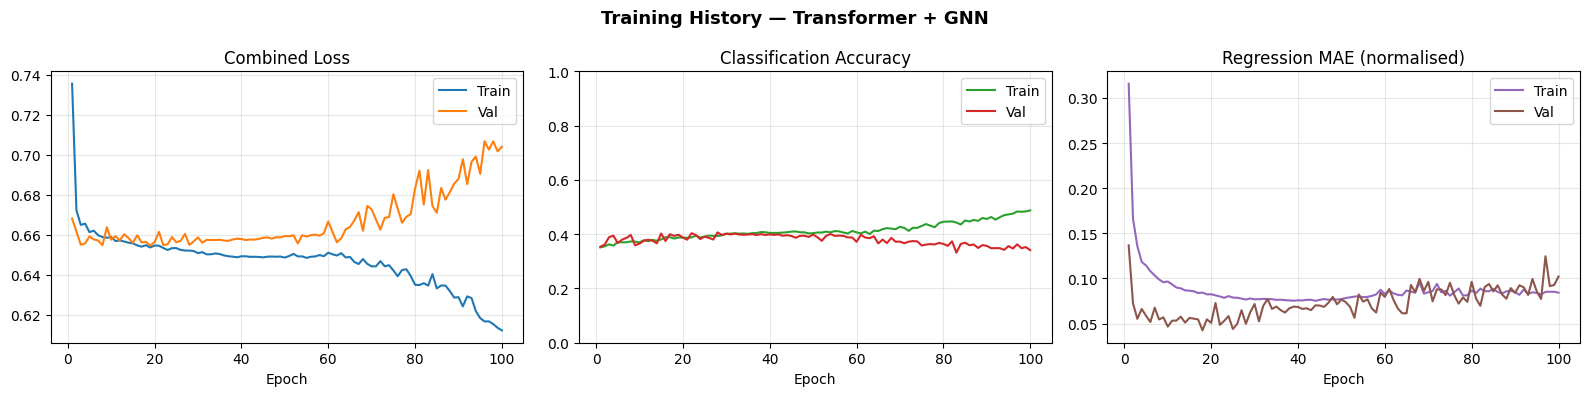

In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training History — Transformer + GNN', fontsize=13, fontweight='bold')

axes[0].plot(epochs_range, history['train_loss'], label='Train', color='#1f77b4')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='#ff7f0e')
axes[0].set_title('Combined Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_cls_acc'], label='Train', color='#2ca02c')
axes[1].plot(epochs_range, history['val_cls_acc'],   label='Val',   color='#d62728')
axes[1].set_title('Classification Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history['train_reg_mae'], label='Train', color='#9467bd')
axes[2].plot(epochs_range, history['val_reg_mae'],   label='Val',   color='#8c564b')
axes[2].set_title('Regression MAE (normalised)'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()


---
## 🧪 Section 9 — Test Evaluation

### 9.1 Classification: Trend Direction


Test Classification Accuracy: 0.3994


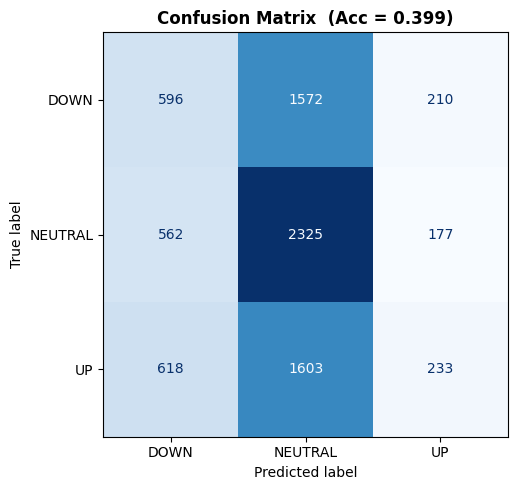

In [ ]:
model.load_state_dict(torch.load('best_transformer_gnn.pt', map_location=DEVICE))
model.eval()

all_preds_c, all_true_c = [], []
all_preds_r, all_true_r = [], []

with torch.no_grad():
    for X, yc, yr in test_loader:
        X, yc, yr = X.to(DEVICE), yc.to(DEVICE), yr.to(DEVICE)
        cls_logits, reg_pred = model(X, A_tensor)
        all_preds_c.extend(cls_logits.argmax(-1).view(-1).cpu().numpy())
        all_true_c.extend(yc.view(-1).cpu().numpy())
        all_preds_r.extend(reg_pred.view(-1).cpu().numpy())
        all_true_r.extend(yr.view(-1).cpu().numpy())

all_preds_c = np.array(all_preds_c)
all_true_c  = np.array(all_true_c)
all_preds_r = np.array(all_preds_r)
all_true_r  = np.array(all_true_r)

cls_acc = accuracy_score(all_true_c, all_preds_c)
print(f'Test Classification Accuracy: {cls_acc:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(all_true_c, all_preds_c)
disp = ConfusionMatrixDisplay(cm, display_labels=['DOWN', 'NEUTRAL', 'UP'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix  (Acc = {cls_acc:.3f})', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


### 9.2 Regression: Next-Day Close Price

REGRESSION RESULTS (de-normalised prices)
  MAE  : 58.07 ₹
  MAPE : 11.70 %
  R²   : 0.8911


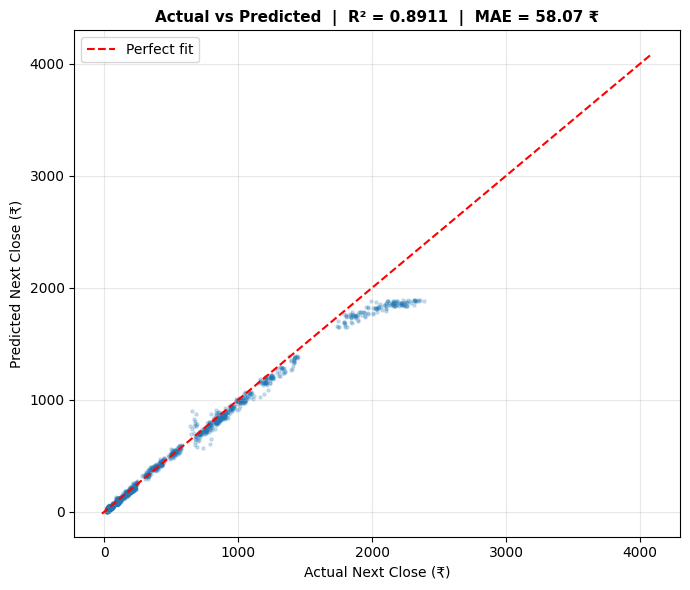

In [ ]:
# De-normalise
pred_denorm = all_preds_r * yr_std + yr_mean
true_denorm = all_true_r  * yr_std + yr_mean

mae  = mean_absolute_error(true_denorm, pred_denorm)
r2   = r2_score(true_denorm, pred_denorm)
mape = np.mean(np.abs((true_denorm - pred_denorm) / (true_denorm + 1e-9))) * 100

print('=' * 50)
print('REGRESSION RESULTS (de-normalised prices)')
print('=' * 50)
print(f'  MAE  : {mae:.2f} ₹')
print(f'  MAPE : {mape:.2f} %')
print(f'  R²   : {r2:.4f}')
print('=' * 50)

# Scatter plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(true_denorm[:2000], pred_denorm[:2000],
           alpha=0.2, s=5, color='#1f77b4')
lims = [min(true_denorm.min(), pred_denorm.min()),
        max(true_denorm.max(), pred_denorm.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Next Close (₹)'); ax.set_ylabel('Predicted Next Close (₹)')
ax.set_title(f'Actual vs Predicted  |  R² = {r2:.4f}  |  MAE = {mae:.2f} ₹',
             fontsize=11, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## 🔬 Section 10 — Per-Stock Evaluation


In [ ]:
results = []
model.eval()

with torch.no_grad():
    for X, yc, yr in test_loader:
        X, yc, yr = X.to(DEVICE), yc.to(DEVICE), yr.to(DEVICE)
        cls_logits, reg_pred = model(X, A_tensor)
        # (B, N) level
        preds_c = cls_logits.argmax(-1).cpu().numpy()   # (B, N)
        true_c  = yc.cpu().numpy()
        preds_r = reg_pred.cpu().numpy() * yr_std + yr_mean
        true_r  = yr.cpu().numpy() * yr_std + yr_mean
        for b in range(preds_c.shape[0]):
            for n, stock in enumerate(available_stocks):
                results.append({
                    'stock': stock,
                    'pred_cls': preds_c[b, n],
                    'true_cls': true_c[b, n],
                    'pred_price': preds_r[b, n],
                    'true_price': true_r[b, n],
                })

res_df = pd.DataFrame(results)

per_stock = []
for stock, grp in res_df.groupby('stock'):
    acc  = accuracy_score(grp['true_cls'], grp['pred_cls'])
    mae_ = mean_absolute_error(grp['true_price'], grp['pred_price'])
    r2_  = r2_score(grp['true_price'], grp['pred_price'])
    per_stock.append({'stock': stock, 'accuracy': acc, 'MAE': mae_, 'R2': r2_})

per_stock_df = pd.DataFrame(per_stock).sort_values('accuracy', ascending=False)
per_stock_df = per_stock_df.reset_index(drop=True)
print(per_stock_df.to_string(index=False, float_format='{:.3f}'.format))


     stock  accuracy      MAE      R2
     ICICI     0.578   35.240   0.583
  HDFCBANK     0.564   25.650   0.727
       SBI     0.532   35.989   0.906
      AXIS     0.514   37.356   0.812
     KOTAK     0.479   11.292   0.320
   BAJFINS     0.472  167.595  -2.652
   FEDERAL     0.429   10.137   0.881
    INDIAN     0.418   31.431   0.929
       PNB     0.411    8.920   0.176
   BAJFINA     0.411   31.843   0.704
       BOB     0.408   11.877   0.806
MANAPPURAM     0.394   11.767   0.791
       BOI     0.390   13.980   0.461
       YES     0.383    8.783 -33.930
    CANARA     0.383    8.530   0.805
   BANDHAN     0.376   11.447  -0.043
      CBOI     0.376    6.771  -5.762
 IDFCFIRST     0.369    8.157  -0.318
UNION BANK     0.365   15.375   0.355
       UCO     0.362    7.355  -7.735
       J&K     0.351   14.753  -4.950
   EQUITAS     0.344   14.664 -10.344
  INDUSIND     0.330   39.874   0.683
     SOUTH     0.330   10.490  -4.413
      IIFL     0.319   17.748   0.930
     KARUR  

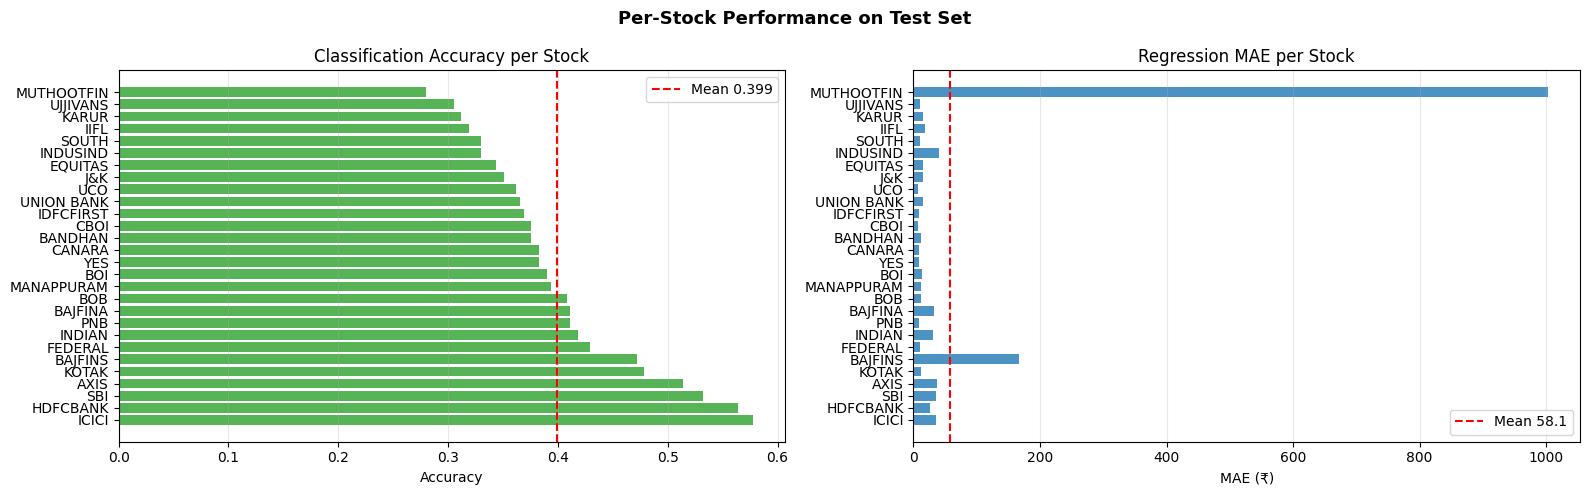

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Per-Stock Performance on Test Set', fontsize=13, fontweight='bold')

axes[0].barh(per_stock_df['stock'], per_stock_df['accuracy'], color='#2ca02c', alpha=0.8)
axes[0].axvline(per_stock_df['accuracy'].mean(), color='red', linestyle='--', label=f'Mean {per_stock_df["accuracy"].mean():.3f}')
axes[0].set_xlabel('Accuracy'); axes[0].set_title('Classification Accuracy per Stock')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='x')

axes[1].barh(per_stock_df['stock'], per_stock_df['MAE'], color='#1f77b4', alpha=0.8)
axes[1].axvline(per_stock_df['MAE'].mean(), color='red', linestyle='--', label=f'Mean {per_stock_df["MAE"].mean():.1f}')
axes[1].set_xlabel('MAE (₹)'); axes[1].set_title('Regression MAE per Stock')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout(); plt.show()


---
## 🔮 Section 11 — Inference: Predict on Latest Data

Predict **trend direction** and **next-day close price** for all 28 stocks
using the most recent 20-day window.


In [ ]:
TREND_LABELS = {0: '🔴 DOWN', 1: '🟡 NEUTRAL', 2: '🟢 UP'}

def predict_latest(df=labeled, stocks=available_stocks):
    """Predict trend + next-close for all stocks from the latest 20-day window."""
    model.eval()
    latest_dates = sorted(df['date'].unique())[-SEQ_LEN:]
    df_window    = df[df['date'].isin(latest_dates)]

    X_w, _, _ = build_graph_dataset(df_window, stocks, scaler)
    if X_w.shape[0] < SEQ_LEN:
        print('Not enough data for inference window.')
        return

    # (1, N, T, F)
    x_in = torch.tensor(X_w[-SEQ_LEN:], dtype=torch.float32)   # (T, N, F)
    x_in = x_in.permute(1, 0, 2).unsqueeze(0).to(DEVICE)        # (1, N, T, F)

    with torch.no_grad():
        cls_logits, reg_pred = model(x_in, A_tensor)
        cls_probs = cls_logits.softmax(-1).squeeze(0).cpu().numpy()  # (N, 3)
        reg_vals  = (reg_pred.squeeze(0).cpu().numpy() * yr_std + yr_mean)  # de-norm

    print(f'\n📊 Latest Predictions  (window ending {latest_dates[-1].date()})')
    print(f"{'Stock':<15} {'Trend':<15} {'Conf':>6}   {'NextClose':>12}")
    print('-' * 55)
    for i, stock in enumerate(stocks):
        pred_cls   = cls_probs[i].argmax()
        confidence = cls_probs[i].max()
        print(f"{stock:<15} {TREND_LABELS[pred_cls]:<15} {confidence:>6.1%}   {reg_vals[i]:>12.2f}")

predict_latest()



📊 Latest Predictions  (window ending 2026-03-19)
Stock           Trend             Conf      NextClose
-------------------------------------------------------
HDFCBANK        🟡 NEUTRAL        44.7%         831.93
IDFCFIRST       🔴 DOWN           39.1%          58.08
ICICI           🟡 NEUTRAL        39.2%        1225.92
KOTAK           🟡 NEUTRAL        38.0%         398.96
AXIS            🟡 NEUTRAL        35.2%        1179.21
SBI             🟡 NEUTRAL        38.1%        1026.57
INDUSIND        🔴 DOWN           34.5%         807.88
UNION BANK      🟢 UP             37.0%         172.70
FEDERAL         🟡 NEUTRAL        35.5%         282.69
BOB             🟢 UP             35.3%         289.96
PNB             🟢 UP             35.3%         106.46
BANDHAN         🟢 UP             38.2%         159.54
CANARA          🟢 UP             35.4%         132.04
INDIAN          🔴 DOWN           36.1%         833.66
UCO             🔴 DOWN           34.5%          26.66
BOI             🟢 UP          

---
## 💾 Section 12 — Save & Reload Model


In [20]:
import os, pickle

SAVE_DIR = 'saved_model_tgnn'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save weights
torch.save(model.state_dict(), f'{SAVE_DIR}/transformer_gnn.pt')

# Save scaler + normalisation stats
with open(f'{SAVE_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

meta = {
    'yr_mean': float(yr_mean), 'yr_std': float(yr_std),
    'available_stocks': available_stocks,
    'INPUT_DIM': INPUT_DIM, 'N_STOCKS': N_STOCKS,
    'FEATURE_COLS': FEATURE_COLS, 'SEQ_LEN': SEQ_LEN,
}
with open(f'{SAVE_DIR}/meta.pkl', 'wb') as f:
    pickle.dump(meta, f)

print(f'✅ Model saved to {SAVE_DIR}/')
print(f'   transformer_gnn.pt — model weights')
print(f'   scaler.pkl         — feature scaler')
print(f'   meta.pkl           — normalisation stats & config')


✅ Model saved to saved_model_tgnn/
   transformer_gnn.pt — model weights
   scaler.pkl         — feature scaler
   meta.pkl           — normalisation stats & config


In [ ]:
# ── How to reload ─────────────────────────────────────────────────────────────
# import pickle, torch
# with open('saved_model_tgnn/scaler.pkl', 'rb') as f: scaler = pickle.load(f)
# with open('saved_model_tgnn/meta.pkl',   'rb') as f: meta   = pickle.load(f)
#
# new_model = TransformerGNNDualHead(
#     input_dim=meta['INPUT_DIM'], num_stocks=meta['N_STOCKS']).to(DEVICE)
# new_model.load_state_dict(torch.load('saved_model_tgnn/transformer_gnn.pt',
#                                       map_location=DEVICE))
# new_model.eval()
print('Reload snippet ready — uncomment to use.')


Reload snippet ready — uncomment to use.


---
## 📝 Section 13 — Next Steps & Customisation Guide

| Area | What to change |
|---|---|
| **Stocks** | Edit `TICKER_MAP` — works with any Yahoo Finance ticker |
| **Graph edges** | Replace `build_correlation_adjacency` with sector graph, supply-chain graph, or knowledge graph |
| **Dynamic graph** | Recompute `A_tensor` each epoch using a rolling correlation window |
| **Attention GNN** | Replace `GCNLayer` with `GATLayer` (Graph Attention Network) for learnable edge weights |
| **Features** | Add order-book depth, news sentiment, macro indicators |
| **Transformer depth** | Increase `num_trans_layers` for longer sequences |
| **Multi-horizon** | Change regression head to predict T+1, T+3, T+7 simultaneously |
